<a href="https://www.kaggle.com/code/wilfriedtsetse04/neurosight-ai-notebook?scriptVersionId=317413847" target="_blank"><img align="left" alt="Kaggle" title="Open in Kaggle" src="https://kaggle.com/static/images/open-in-kaggle.svg"></a>

<a href="https://www.kaggle.com/code/wilfriedtsetse04/neurosight-ai-notebook?scriptVersionId=300807538" target="_blank"><img align="left" alt="Kaggle" title="Open in Kaggle" src="https://kaggle.com/static/images/open-in-kaggle.svg"></a>

In [1]:
import os
import sys
import importlib

# 1. Nettoyage et téléchargement du nouveau pipeline
# Remplace par l'URL de ta branche où tu vas pousser le nouveau data_pipeline.py
GITHUB_RAW_URL = "https://raw.githubusercontent.com/wekt2k04/NeuroSight_AI/dev-leila2/notebooks/data_pipeline.py"

print("📥 Mise à jour du pipeline NeuroSight...")
!wget -q -O data_pipeline.py {GITHUB_RAW_URL}

if '/kaggle/working' not in sys.path:
    sys.path.append('/kaggle/working')

# 2. Importation dynamique
try:
    import data_pipeline
    importlib.reload(data_pipeline)
    from data_pipeline import prepare_data, show_sample_batch, plot_class_distribution
    print("✅ Pipeline 'Feature Engineered' chargé avec succès.")
except Exception as e:
    print(f"❌ Erreur d'import : {e}")

📥 Mise à jour du pipeline NeuroSight...
✅ Pipeline 'Feature Engineered' chargé avec succès.


📖 Loading clinical data + MICE imputation...
   ✅ MICE imputation done.
🔍 Scanning images: /kaggle/input/datasets/ninadaithal/imagesoasis/Data
   ✅ 47580 images linked.

🛡️ Stratified Group Split (patient-level, class-balanced)...

📊 INITIAL SPLIT STATISTICS:
   Train: {0: np.int64(20252), 1: np.int64(10004), 2: np.int64(3599), 3: np.int64(244)}
   Val: {0: np.int64(4087), 1: np.int64(1891), 2: np.int64(671), 3: np.int64(244)}
   Test: {0: np.int64(4026), 1: np.int64(1830), 2: np.int64(732)}

🔄 Ensuring test set has all classes...

   Original test counts: {0: np.int64(4026), 1: np.int64(1830), 2: np.int64(732)}
   Moved 50 samples of class 3 from train to test
   New test counts: {0: np.int64(4026), 1: np.int64(1830), 2: np.int64(732), 3: np.int64(50)}

⚖️ STAGE 1: Balancing TRAIN set to 5000 samples per class...
   Class 0: undersampled from 20252 to 5000
   Class 1: undersampled from 10004 to 5000
   Class 2: oversampled from 3599 to 5000
   Class 3: oversampled from 194 to 5000

  

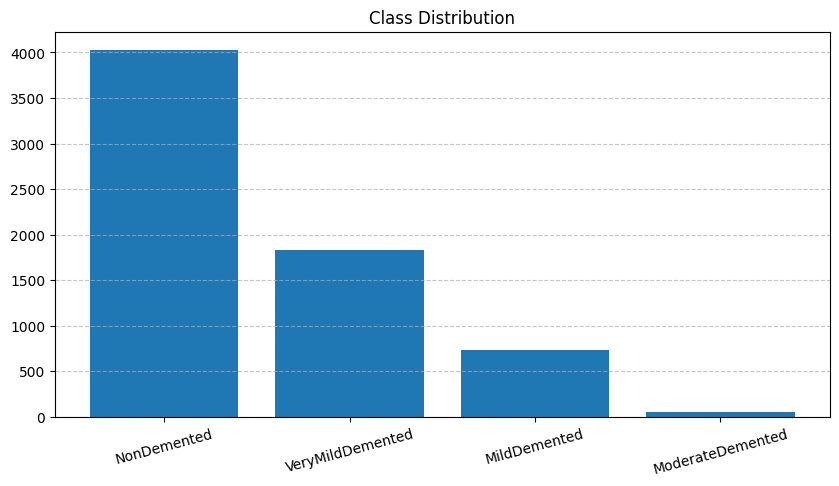

In [2]:
# --- CONFIGURATION DES CHEMINS ---
# Assure-toi que ces chemins correspondent à tes inputs Kaggle
CSV_PATH = '/kaggle/input/datasets/wilfriedtsetse04/mon-csv-officiel/oasis_cross-sectional-5708aa0a98d82080.xlsx'
IMAGES_DIR = '/kaggle/input/datasets/ninadaithal/imagesoasis/Data'

# --- CRÉATION DES LOADERS ---
# Note : on utilise la nouvelle fonction 'prepare_data'

# train_loader, val_loader, test_loader, classes = prepare_data(
#     csv_path=CSV_PATH, 
#     images_dir=IMAGES_DIR, 
#     batch_size=32
# )

# Prepare data with balanced test set
train_loader, val_loader, test_loader, classes = prepare_data(
    csv_path=CSV_PATH,
    images_dir=IMAGES_DIR,
    batch_size=32,
    val_split=0.15,
    test_split=0.15,
    target_train_per_class=5000,
    target_test_per_class=50  # Ensures at least 50 Moderate Demented samples in test
)

# Verify the test set has all classes
plot_class_distribution(test_loader, classes)

# Then train as before, but evaluate on test_loader at the end

# # --- AUDIT VISUEL ---
# print(f"\n🚀 Classes prêtes : {classes}")
# plot_class_distribution(train_loader, classes)
# show_sample_batch(train_loader, classes)


🖥️ DEVICE: cuda
Downloading: "https://download.pytorch.org/models/efficientnet_b2_rwightman-c35c1473.pth" to /root/.cache/torch/hub/checkpoints/efficientnet_b2_rwightman-c35c1473.pth


100%|██████████| 35.2M/35.2M [00:01<00:00, 30.4MB/s]


🚀 START TRAINING NEUROSIGHT MODEL (Anti-Overfitting Mode)
   Dropout: 0.7
   Warmup epochs: 15
   Unfreeze blocks: 2
   LR Head: 0.0001
   LR Backbone: 1e-06

📌 Epoch 1/60
----------------------------------------


Train Loss: 0.7173
Val Loss  : 0.5871
Val Macro-F1: 0.2697
Per-class F1: N=0.661, V=0.383, M=0.026, Mod=0.009
Best F1   : 0.0000
Patience  : 0/10
✅ New best model saved

📌 Epoch 2/60
----------------------------------------
Train Loss: 0.6292
Val Loss  : 0.6051
Val Macro-F1: 0.2613
Per-class F1: N=0.595, V=0.411, M=0.036, Mod=0.004
Best F1   : 0.2697
Patience  : 0/10

📌 Epoch 3/60
----------------------------------------
Train Loss: 0.6114
Val Loss  : 0.5971
Val Macro-F1: 0.2590
Per-class F1: N=0.569, V=0.438, M=0.025, Mod=0.005
Best F1   : 0.2697
Patience  : 1/10

📌 Epoch 4/60
----------------------------------------
Train Loss: 0.5979
Val Loss  : 0.6249
Val Macro-F1: 0.2414
Per-class F1: N=0.503, V=0.418, M=0.038, Mod=0.007
Best F1   : 0.2697
Patience  : 2/10

📌 Epoch 5/60
----------------------------------------
Train Loss: 0.5806
Val Loss  : 0.6153
Val Macro-F1: 0.2447
Per-class F1: N=0.504, V=0.447, M=0.023, Mod=0.004
Best F1   : 0.2697
Patience  : 3/10

📌 Epoch 6/60
-------------

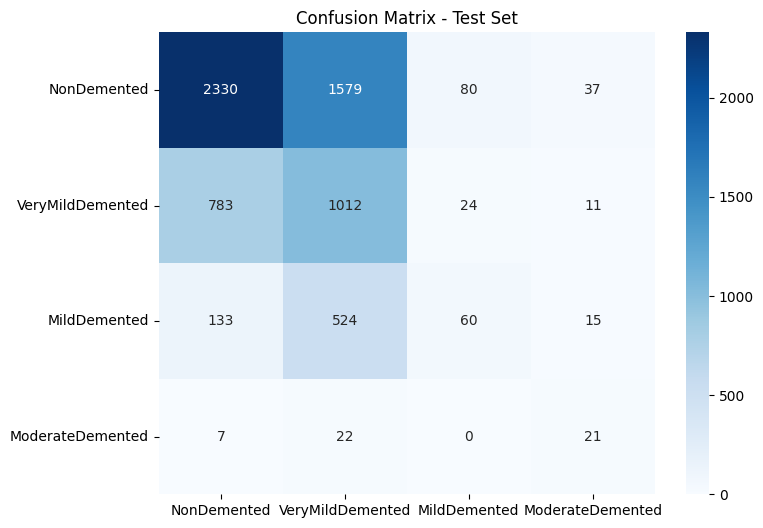

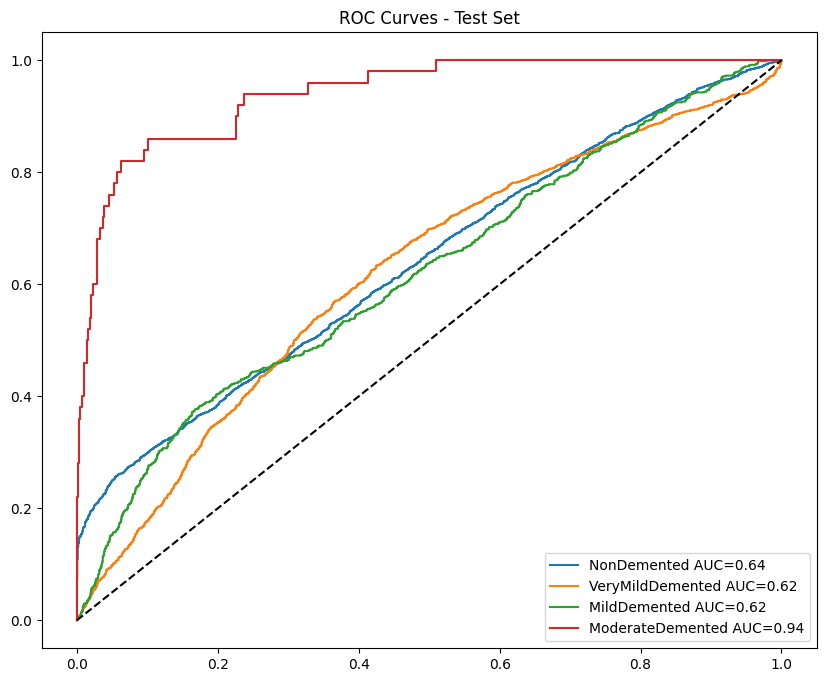


📊 Per-Class Performance:
--------------------------------------------------
NonDemented          | Precision: 0.7163 | Recall: 0.5787 | F1: 0.6402
VeryMildDemented     | Precision: 0.3226 | Recall: 0.5530 | F1: 0.4075
MildDemented         | Precision: 0.3659 | Recall: 0.0820 | F1: 0.1339
ModerateDemented     | Precision: 0.2500 | Recall: 0.4200 | F1: 0.3134
--------------------------------------------------
Macro AVG     | Precision: 0.4137 | Recall: 0.4084 | F1: 0.3738
Weighted AVG  | Precision: 0.5656 | Recall: 0.5157 | F1: 0.5178


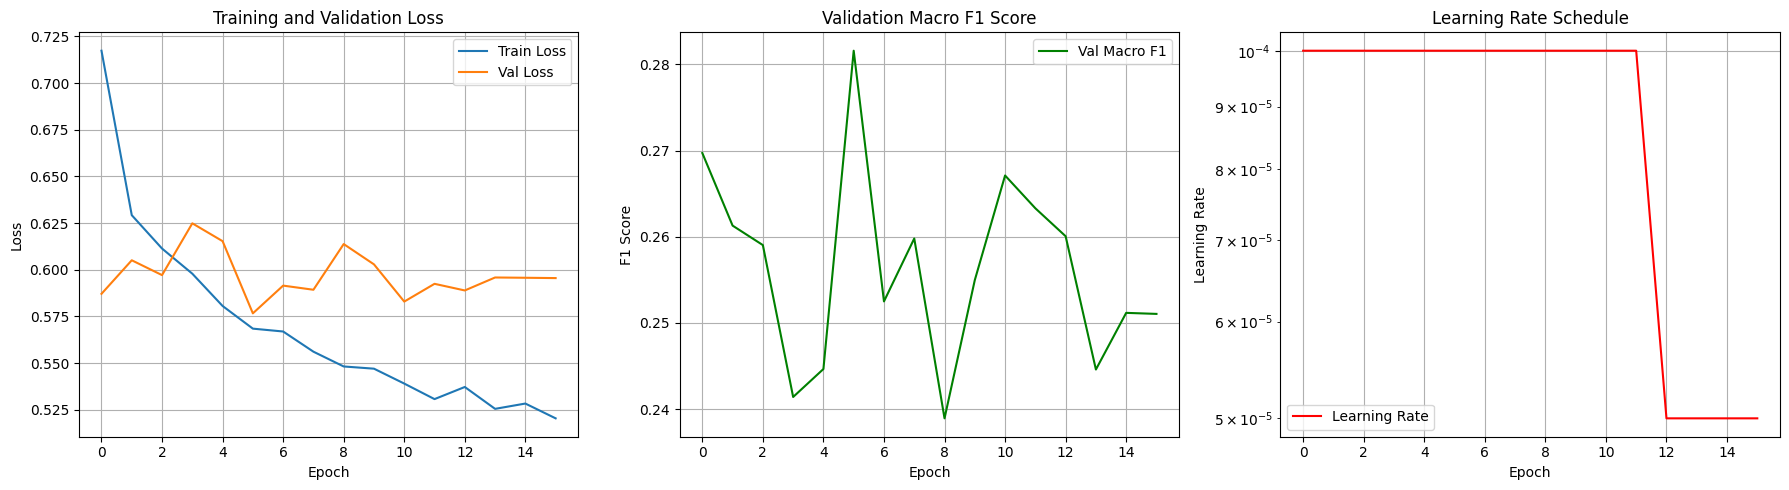


✅ Model saved to 'neurosight_model_complete.pth'


In [3]:
# ==========================================================
# CELLULE 3 : ENTRAÎNEMENT & AUDIT DES MÉTRIQUES (SEMAINE 2)
# FIXED VERSION - Anti-Overfitting Measures Applied
# ==========================================================
import torch
import torch.nn as nn
import torch.optim as optim
from torchvision import models
from sklearn.metrics import classification_report, confusion_matrix, roc_curve, auc, f1_score, recall_score
from sklearn.preprocessing import label_binarize
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import copy
from torch.optim.lr_scheduler import CosineAnnealingLR, ReduceLROnPlateau
import torch.nn.functional as F


# ==========================================================
# FOCAL LOSS
# ==========================================================
class FocalLoss(nn.Module):
    def __init__(self, gamma=2.0, label_smoothing=0.05):
        super().__init__()
        self.gamma = gamma
        self.ls = label_smoothing

    def forward(self, logits, targets):
        ce = F.cross_entropy(
            logits,
            targets,
            reduction='none',
            label_smoothing=self.ls
        )
        pt = torch.exp(-ce)
        focal_weight = (1 - pt) ** self.gamma
        return (focal_weight * ce).mean()


# ==========================================================
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"\n🖥️ DEVICE: {device}")


# ==========================================================
# MODEL - WITH INCREASED DROPOUT (0.7 instead of 0.5)
# ==========================================================
def build_neurosight_model(num_classes, dropout=0.7):
    """
    Builds EfficientNet-B2 model with increased dropout for better regularization.
    """
    model = models.efficientnet_b2(weights=models.EfficientNet_B2_Weights.IMAGENET1K_V1)
    
    # Freeze all layers initially
    for p in model.parameters():
        p.requires_grad = False

    in_f = model.classifier[1].in_features

    # Custom classifier with higher dropout rates
    model.classifier = nn.Sequential(
        nn.Dropout(dropout),                    # Increased from 0.5 to 0.7
        nn.Linear(in_f, 512),
        nn.BatchNorm1d(512),
        nn.ReLU(inplace=True),
        nn.Dropout(dropout / 2),                # Now 0.35
        nn.Linear(512, num_classes),
    )
    return model.to(device)


def unfreeze_top_blocks(model, num_blocks=2):
    """
    Unfreeze only top blocks (reduced from 3 to 2 for slower fine-tuning)
    """
    layers = list(model.features.children())
    for layer in layers[-num_blocks:]:
        for p in layer.parameters():
            p.requires_grad = True


# ==========================================================
# TRAINING LOOP - WITH FIXED HYPERPARAMETERS
# ==========================================================
def train_model(model, train_loader, val_loader,
                num_epochs=60,
                warmup_epochs=15,      # Increased from 10 to 15
                unfreeze_blocks=2,     # Reduced from 3 to 2
                patience=10,
                lr_head=1e-4,          # Reduced from 1e-3
                lr_backbone=1e-6):     # Reduced from 3e-5/5e-6

    print("\n🚀 START TRAINING NEUROSIGHT MODEL (Anti-Overfitting Mode)")
    print("=" * 60)
    print(f"   Dropout: 0.7")
    print(f"   Warmup epochs: {warmup_epochs}")
    print(f"   Unfreeze blocks: {unfreeze_blocks}")
    print(f"   LR Head: {lr_head}")
    print(f"   LR Backbone: {lr_backbone}")
    print("=" * 60)

    criterion = FocalLoss(gamma=2.0, label_smoothing=0.05)

    # Optimizer with proper weight decay
    optimizer = optim.AdamW([
        {'params': model.classifier.parameters(), 'lr': lr_head, 'weight_decay': 1e-4},
        {'params': model.features.parameters(), 'lr': 0.0, 'weight_decay': 1e-4},
    ], weight_decay=1e-4)

    # Use ReduceLROnPlateau without verbose parameter (removed in newer PyTorch)
    scheduler = ReduceLROnPlateau(
        optimizer, 
        mode='min', 
        factor=0.5, 
        patience=5
    )

    best_f1 = 0.0
    best_weights = None
    epochs_no_improve = 0

    history = {
        "train_loss": [],
        "val_loss": [],
        "val_f1": [],
        "learning_rates": []
    }

    for epoch in range(num_epochs):

        # ================= UNFREEZE =================
        if epoch == warmup_epochs:
            print("\n🔓 PHASE 2: UNFREEZING BACKBONE")
            unfreeze_top_blocks(model, unfreeze_blocks)
            optimizer.param_groups[1]['lr'] = lr_backbone
            print(f"   Backbone LR set to: {lr_backbone}")

        print(f"\n📌 Epoch {epoch+1}/{num_epochs}")
        print("-" * 40)

        # ================= TRAIN =================
        model.train()
        train_loss = 0

        for images, labels in train_loader:
            images, labels = images.to(device), labels.to(device)

            optimizer.zero_grad()
            outputs = model(images)
            loss = criterion(outputs, labels)

            loss.backward()
            torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
            optimizer.step()

            train_loss += loss.item()

        avg_train_loss = train_loss / len(train_loader)

        # ================= VALIDATION =================
        model.eval()
        val_loss = 0
        all_preds, all_labels = [], []

        with torch.no_grad():
            for images, labels in val_loader:
                images, labels = images.to(device), labels.to(device)

                outputs = model(images)
                loss = criterion(outputs, labels)

                preds = outputs.argmax(1)

                val_loss += loss.item()
                all_preds.extend(preds.cpu().numpy())
                all_labels.extend(labels.cpu().numpy())

        avg_val_loss = val_loss / len(val_loader)
        val_f1 = f1_score(all_labels, all_preds, average='macro', zero_division=0)
        
        # Per-class F1 for monitoring
        per_class_f1 = f1_score(all_labels, all_preds, average=None, zero_division=0)

        history["train_loss"].append(avg_train_loss)
        history["val_loss"].append(avg_val_loss)
        history["val_f1"].append(val_f1)
        history["learning_rates"].append(optimizer.param_groups[0]['lr'])

        # ================= LOGS =================
        print(f"Train Loss: {avg_train_loss:.4f}")
        print(f"Val Loss  : {avg_val_loss:.4f}")
        print(f"Val Macro-F1: {val_f1:.4f}")
        print(f"Per-class F1: N={per_class_f1[0]:.3f}, V={per_class_f1[1]:.3f}, M={per_class_f1[2]:.3f}, Mod={per_class_f1[3]:.3f}")
        print(f"Best F1   : {best_f1:.4f}")
        print(f"Patience  : {epochs_no_improve}/{patience}")

        # ================= SAVE BEST =================
        if val_f1 > best_f1:
            best_f1 = val_f1
            best_weights = copy.deepcopy(model.state_dict())
            torch.save(best_weights, "best_neurosight.pth")
            epochs_no_improve = 0
            print("✅ New best model saved")
        else:
            epochs_no_improve += 1

        # Step scheduler with validation loss
        scheduler.step(avg_val_loss)
        
        # Print learning rate reduction if it changed
        current_lr = optimizer.param_groups[0]['lr']
        if len(history["learning_rates"]) > 1 and current_lr != history["learning_rates"][-2]:
            print(f"📉 Learning rate reduced to: {current_lr}")

        if epochs_no_improve >= patience:
            print("\n🛑 EARLY STOPPING TRIGGERED")
            break

    # Load best weights
    model.load_state_dict(best_weights)
    print(f"\n✅ Training complete. Best Macro F1: {best_f1:.4f}")
    
    return model, history


# ==========================================================
# EVALUATION FUNCTION (UPDATED TO WORK WITH TEST SET)
# ==========================================================
def evaluate_on_test(model, test_loader, class_names):
    """
    Evaluate model on held-out test set and print metrics.
    """
    print("\n📋 FINAL CLINICAL REPORT - TEST SET")
    print("=" * 60)

    model.eval()
    y_true, y_pred, y_probs = [], [], []

    with torch.no_grad():
        for images, labels in test_loader:
            images = images.to(device)

            outputs = model(images)
            probs = torch.softmax(outputs, dim=1)
            preds = outputs.argmax(1)

            y_true.extend(labels.numpy())
            y_pred.extend(preds.cpu().numpy())
            y_probs.extend(probs.cpu().numpy())

    y_probs = np.array(y_probs)

    # ================= CLASSIFICATION REPORT =================
    print("\nClassification Report:")
    print(classification_report(
        y_true,
        y_pred,
        target_names=class_names,
        zero_division=0
    ))

    # ================= CONFUSION MATRIX =================
    cm = confusion_matrix(y_true, y_pred)

    plt.figure(figsize=(8, 6))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=class_names,
                yticklabels=class_names)
    plt.title("Confusion Matrix - Test Set")
    plt.show()

    # ================= ROC CURVES =================
    y_true_bin = label_binarize(y_true, classes=range(len(class_names)))

    plt.figure(figsize=(10, 8))

    for i in range(len(class_names)):
        if np.sum(y_true_bin[:, i]) > 0:
            fpr, tpr, _ = roc_curve(y_true_bin[:, i], y_probs[:, i])
            roc_auc = auc(fpr, tpr)
            plt.plot(fpr, tpr, label=f"{class_names[i]} AUC={roc_auc:.2f}")

    plt.plot([0, 1], [0, 1], 'k--')
    plt.title("ROC Curves - Test Set")
    plt.legend()
    plt.show()
    
    # ================= PER-CLASS METRICS =================
    from sklearn.metrics import precision_recall_fscore_support
    
    precision, recall, f1, _ = precision_recall_fscore_support(y_true, y_pred, average=None, zero_division=0)
    
    print("\n📊 Per-Class Performance:")
    print("-" * 50)
    for i, name in enumerate(class_names):
        print(f"{name:20} | Precision: {precision[i]:.4f} | Recall: {recall[i]:.4f} | F1: {f1[i]:.4f}")
    
    # Macro and weighted averages
    macro_precision, macro_recall, macro_f1, _ = precision_recall_fscore_support(
        y_true, y_pred, average='macro', zero_division=0
    )
    weighted_precision, weighted_recall, weighted_f1, _ = precision_recall_fscore_support(
        y_true, y_pred, average='weighted', zero_division=0
    )
    
    print("-" * 50)
    print(f"Macro AVG     | Precision: {macro_precision:.4f} | Recall: {macro_recall:.4f} | F1: {macro_f1:.4f}")
    print(f"Weighted AVG  | Precision: {weighted_precision:.4f} | Recall: {weighted_recall:.4f} | F1: {weighted_f1:.4f}")
    
    return y_true, y_pred, y_probs


# ==========================================================
# PLOT TRAINING HISTORY
# ==========================================================
def plot_training_history(history):
    fig, axes = plt.subplots(1, 3, figsize=(18, 5))
    
    # Loss plot
    axes[0].plot(history['train_loss'], label='Train Loss')
    axes[0].plot(history['val_loss'], label='Val Loss')
    axes[0].set_xlabel('Epoch')
    axes[0].set_ylabel('Loss')
    axes[0].set_title('Training and Validation Loss')
    axes[0].legend()
    axes[0].grid(True)
    
    # F1 Score plot
    axes[1].plot(history['val_f1'], label='Val Macro F1', color='green')
    axes[1].set_xlabel('Epoch')
    axes[1].set_ylabel('F1 Score')
    axes[1].set_title('Validation Macro F1 Score')
    axes[1].legend()
    axes[1].grid(True)
    
    # Learning Rate plot
    axes[2].plot(history['learning_rates'], label='Learning Rate', color='red')
    axes[2].set_xlabel('Epoch')
    axes[2].set_ylabel('Learning Rate')
    axes[2].set_title('Learning Rate Schedule')
    axes[2].set_yscale('log')
    axes[2].legend()
    axes[2].grid(True)
    
    plt.tight_layout()
    plt.show()


# ==========================================================
# MAIN EXECUTION
# ==========================================================

# First, load your data (this should be done before building the model)
# train_loader, val_loader, test_loader, classes = prepare_data(...)

# Build the model with HIGHER DROPOUT (0.7 instead of 0.5)
model = build_neurosight_model(len(classes), dropout=0.7)

# Train the model using the FIXED hyperparameters
best_model, training_history = train_model(
    model,
    train_loader,      # Now balanced! (5000 per class)
    val_loader,        # For early stopping and validation
    num_epochs=60,
    warmup_epochs=15,  # Later unfreezing
    unfreeze_blocks=2, # Unfreeze fewer blocks
    patience=10,
    lr_head=1e-4,      # Lower head learning rate
    lr_backbone=1e-6   # Lower backbone learning rate
)

# ==========================================================
# FINAL EVALUATION ON TEST SET (NOT VALIDATION SET!)
# ==========================================================
print("\n" + "="*60)
print("FINAL EVALUATION ON HELD-OUT TEST SET")
print("="*60)

# Evaluate on test_loader (NOT val_loader)
y_true, y_pred, y_probs = evaluate_on_test(best_model, test_loader, classes)

# Plot training history
plot_training_history(training_history)

# ==========================================================
# SAVE MODEL FOR LATER USE
# ==========================================================
torch.save({
    'model_state_dict': best_model.state_dict(),
    'history': training_history,
    'class_names': classes,
}, 'neurosight_model_complete.pth')
print("\n✅ Model saved to 'neurosight_model_complete.pth'")

# Metrics analysis
#### The core problem is **severe overfitting** The model essentially memorised the training set:

    -Train accuracy: 99.9% — Val accuracy: 66.6% (a 33-point gap)
    -Train loss: 0.004 — Val loss: 2.17 (val loss rose monotonically from epoch 1)
    -Per-class F1: NonDemented (0.78), VeryMild (0.51), Mild (0.14), Moderate (0.00 — no samples even reached the val set)
    -Macro F1 only 0.36 — useless for a clinical tool that must detect all severity stages

## The four root causes: 
    -(1) full fine-tuning from epoch 1 destroys pretrained features too quickly, 
    -(2) no early stopping
    -(3) weak augmentation
    -(4) class imbalance in the validation split means Moderate Dementia literally never appears in evaluation.
